In [62]:
import os
import re
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from scipy import signal, stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt


In [63]:
ROOT = Path(r"E:\Upwork Project\AI_Leak_Detection_Project\data\raw")

ACC_DIR = ROOT / "Accelerometer"
PRES_DIR = ROOT / "Dynamic Pressure Sensor"
HYD_DIR  = ROOT / "Hydrophone"

# Hydrophone sampling rate (given by dataset description)
FS_HYD = 8000

# Optional: if accelerometer/pressure CSVs include a time column, we’ll infer Fs from it.
# If not, we’ll compute Fs from metadata or file contents if possible.


In [64]:
@dataclass
class RecordMeta:
    topology: str     # BR / LO
    leak: str         # CC / LC / GL / OL / NL
    flow: str         # ND / 0.18 LPS / 0.47 LPS / T
    sensor_type: str  # A / P / H
    sensor_id: str    # 1 / 2
    noise: Optional[str] = None  # N / NN only for hydrophone

def parse_meta_from_name(fname: str) -> RecordMeta:
    name = Path(fname).stem  # remove extension

    # Hydrophone: T_L_F_B_S#
    # Example: LO_OL_ND_N_H2
    m = re.match(r"^(BR|LO)_(CC|LC|GL|OL|NL)_(ND|0\.18 LPS|0\.47 LPS|T)_(N|NN)_(H)(\d)$", name)
    if m:
        topo, leak, flow, noise, stype, sid = m.groups()
        return RecordMeta(topo, leak, flow, stype, sid, noise=noise)

    # Acc/Pressure: T_L_F_S#
    # Example: BR_CC_0.18 LPS_A1
    m = re.match(r"^(BR|LO)_(CC|LC|GL|OL|NL)_(ND|0\.18 LPS|0\.47 LPS|T)_(A|P)(\d)$", name)
    if m:
        topo, leak, flow, stype, sid = m.groups()
        return RecordMeta(topo, leak, flow, stype, sid)

    raise ValueError(f"Unrecognized filename pattern: {fname}")


In [65]:
def collect_files(base: Path, ext: str) -> List[Path]:
    return sorted([p for p in base.rglob(f"*{ext}") if p.is_file()])

acc_files = collect_files(ACC_DIR, ".csv")
pres_files = collect_files(PRES_DIR, ".csv")
hyd_files = collect_files(HYD_DIR, ".raw")

rows = []
for p in acc_files + pres_files + hyd_files:
    try:
        meta = parse_meta_from_name(p.name)
        rows.append({
            "path": str(p),
            "topology": meta.topology,
            "leak": meta.leak,
            "flow": meta.flow,
            "sensor_type": meta.sensor_type,
            "sensor_id": meta.sensor_id,
            "noise": meta.noise if meta.noise else "NA",
            "ext": p.suffix.lower()
        })
    except Exception as e:
        # keep a log row for debugging
        rows.append({"path": str(p), "error": str(e), "ext": p.suffix.lower()})

df_index = pd.DataFrame(rows)

print("Total indexed:", len(df_index))
display(df_index.head(10))


Total indexed: 282


,path,topology,leak,flow,sensor_type,sensor_id,noise,ext,error
0,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,A,1,NA,.csv,NaN
1,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,A,2,NA,.csv,NaN
2,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,A,1,NA,.csv,NaN
3,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,A,2,NA,.csv,NaN
4,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,A,1,NA,.csv,NaN
5,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,A,2,NA,.csv,NaN
6,E:\Upwork Project\AI_Leak_Detection_Project\da...,NaN,NaN,NaN,NaN,NaN,NaN,.csv,Unrecognized filename pattern: BR_CC_Transient...
7,E:\Upwork Project\AI_Leak_Detection_Project\da...,NaN,NaN,NaN,NaN,NaN,NaN,.csv,Unrecognized filename pattern: BR_CC_Transient...
8,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,GL,0.18 LPS,A,1,NA,.csv,NaN
9,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,GL,0.18 LPS,A,2,NA,.csv,NaN


In [66]:
df = df_index[df_index.get("error").isna()].copy()
df.reset_index(drop=True, inplace=True)

print("Usable files:", len(df))
print(df["sensor_type"].value_counts())
display(df.sample(10, random_state=0))


Usable files: 200
sensor_type
H    80
A    60
P    60
Name: count, dtype: int64


,path,topology,leak,flow,sensor_type,sensor_id,noise,ext,error
18,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,NL,0.18 LPS,A,1,NA,.csv,NaN
170,E:\Upwork Project\AI_Leak_Detection_Project\da...,LO,GL,0.47 LPS,H,1,N,.raw,NaN
107,E:\Upwork Project\AI_Leak_Detection_Project\da...,LO,LC,ND,P,2,NA,.csv,NaN
98,E:\Upwork Project\AI_Leak_Detection_Project\da...,LO,GL,0.47 LPS,P,1,NA,.csv,NaN
177,E:\Upwork Project\AI_Leak_Detection_Project\da...,LO,LC,0.18 LPS,H,2,N,.raw,NaN
182,E:\Upwork Project\AI_Leak_Detection_Project\da...,LO,LC,ND,H,1,NN,.raw,NaN
5,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,A,2,NA,.csv,NaN
146,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,NL,0.47 LPS,H,1,N,.raw,NaN
12,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,LC,0.18 LPS,A,1,NA,.csv,NaN
152,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,OL,0.18 LPS,H,1,N,.raw,NaN


In [67]:
def load_csv_signal(path: str) -> np.ndarray:
    x = pd.read_csv(path)

    # If there is a time column, drop it and keep the measurement col.
    # Otherwise choose the first numeric column.
    numeric_cols = x.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError(f"No numeric columns in {path}")

    # If there are 2 numeric columns and one looks like time, prefer the other
    if len(numeric_cols) >= 2:
        # heuristic: time column monotonic increasing with small step
        best = None
        for c in numeric_cols:
            v = x[c].values
            if np.all(np.diff(v) > 0) and (np.nanmax(v) - np.nanmin(v) > 1.0):
                # likely time
                continue
            best = c
            break
        col = best if best else numeric_cols[-1]
    else:
        col = numeric_cols[0]

    sig = x[col].astype(float).values
    sig = np.nan_to_num(sig)
    return sig


In [68]:
def load_raw_hydrophone(path: str, dtype=np.int16) -> np.ndarray:
    data = np.fromfile(path, dtype=dtype)
    data = data.astype(np.float32)

    # normalize for stable processing
    if np.max(np.abs(data)) > 0:
        data /= np.max(np.abs(data))
    return data


A len: 923488 fs: -1 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'NA', 'sensor_id': '1'}


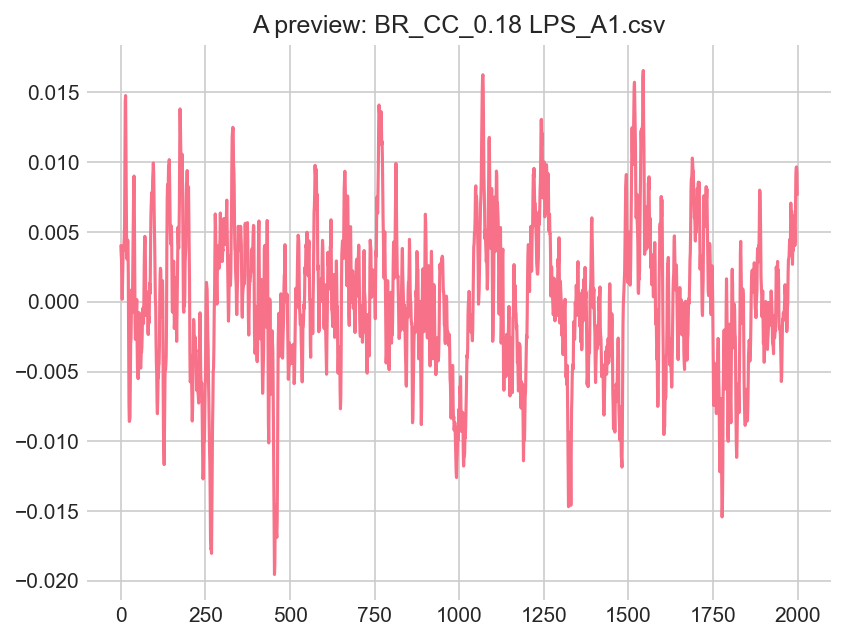

P len: 943716 fs: -1 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'NA', 'sensor_id': '1'}


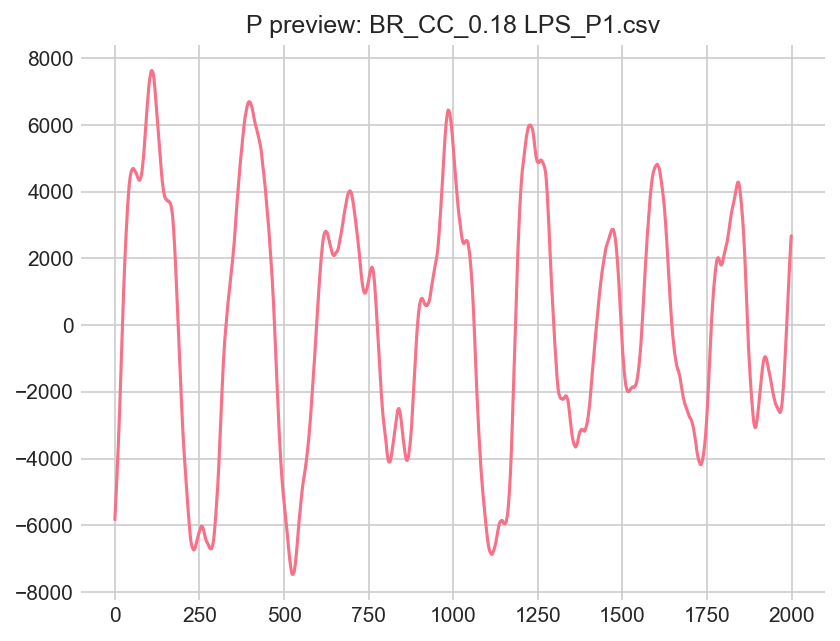

H len: 642920 fs: 8000 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'N', 'sensor_id': '1'}


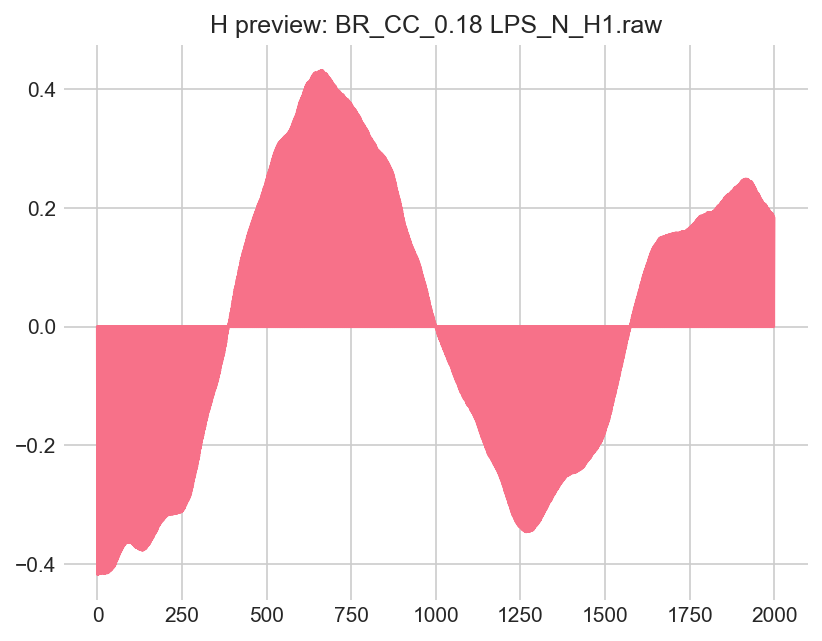

In [69]:
def load_signal(row: pd.Series) -> Tuple[np.ndarray, int]:
    if row["sensor_type"] in ["A", "P"] and row["ext"] == ".csv":
        x = load_csv_signal(row["path"])
        fs = -1  # unknown for now
        return x, fs
    if row["sensor_type"] == "H" and row["ext"] == ".raw":
        x = load_raw_hydrophone(row["path"], dtype=np.int16)
        return x, FS_HYD
    raise ValueError("Unsupported type")

# pick one of each
for stype in ["A", "P", "H"]:
    r = df[df["sensor_type"] == stype].iloc[0]
    x, fs = load_signal(r)
    print(stype, "len:", len(x), "fs:", fs, "meta:", r[["topology","leak","flow","noise","sensor_id"]].to_dict())
    plt.figure()
    plt.plot(x[:2000] if len(x) > 2000 else x)
    plt.title(f"{stype} preview: {Path(r['path']).name}")
    plt.show()


In [70]:
def preprocess(x: np.ndarray, fs: int, detrend=True, normalize=True, band=None) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)

    if detrend:
        x = signal.detrend(x)

    if band is not None and fs > 0:
        low, high = band
        sos = signal.butter(4, [low, high], btype="bandpass", fs=fs, output="sos")
        x = signal.sosfiltfilt(sos, x)

    if normalize:
        s = np.std(x) + 1e-9
        x = (x - np.mean(x)) / s

    return x


In [71]:
def time_features(x: np.ndarray) -> Dict[str, float]:
    return {
        "rms": float(np.sqrt(np.mean(x**2))),
        "std": float(np.std(x)),
        "kurtosis": float(stats.kurtosis(x, fisher=False)),
        "skew": float(stats.skew(x)),
        "crest_factor": float(np.max(np.abs(x)) / (np.sqrt(np.mean(x**2)) + 1e-9)),
    }


In [72]:
def psd_band_energies(x: np.ndarray, fs: int, bands: List[Tuple[float,float]]) -> Dict[str, float]:
    f, Pxx = signal.welch(x, fs=fs, nperseg=min(4096, len(x)))
    feats = {}
    total = np.trapz(Pxx, f) + 1e-12

    for (lo, hi) in bands:
        m = (f >= lo) & (f < hi)
        e = np.trapz(Pxx[m], f[m]) / total
        feats[f"psd_e_{lo:.0f}_{hi:.0f}"] = float(e)
    return feats


In [73]:
def spectral_entropy(x: np.ndarray, fs: int) -> float:
    f, Pxx = signal.welch(x, fs=fs, nperseg=min(4096, len(x)))
    P = Pxx / (np.sum(Pxx) + 1e-12)
    return float(-np.sum(P * np.log(P + 1e-12)))


In [74]:
BANDS_H = [(0,50),(50,150),(150,300),(300,600),(600,1200),(1200,2000),(2000,3500)]


In [75]:
hyd_df = df[df["sensor_type"] == "H"].copy().reset_index(drop=True)

feat_rows = []
for i, row in hyd_df.iterrows():
    x, fs = load_signal(row)
    x = preprocess(x, fs=fs, detrend=True, normalize=True, band=(20, 3500))

    feats = {}
    feats.update(time_features(x))
    feats.update(psd_band_energies(x, fs, BANDS_H))
    feats["spec_entropy"] = spectral_entropy(x, fs)

    feat_rows.append({**row.to_dict(), **feats})

hyd_feat = pd.DataFrame(feat_rows)
print("Hydrophone feature table:", hyd_feat.shape)
display(hyd_feat.head())


Hydrophone feature table: (80, 22)


,path,topology,leak,flow,sensor_type,sensor_id,noise,ext,error,rms,...,skew,crest_factor,psd_e_0_50,psd_e_50_150,psd_e_150_300,psd_e_300_600,psd_e_600_1200,psd_e_1200_2000,psd_e_2000_3500,spec_entropy
0,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,H,1,N,.raw,NaN,1.0,...,-0.116895,25.729829,0.955231,0.040280,0.000050,0.001426,0.000363,0.000108,0.000492,2.074690
1,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,H,2,N,.raw,NaN,1.0,...,-1.160470,49.526431,0.783295,0.029334,0.004389,0.067270,0.030365,0.021157,0.053068,3.633535
2,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,H,1,N,.raw,NaN,1.0,...,-0.123274,56.102244,0.933619,0.028003,0.000090,0.014150,0.005795,0.005172,0.011107,2.460710
3,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,H,2,N,.raw,NaN,1.0,...,-1.238804,48.379729,0.928292,0.020566,0.002659,0.019803,0.005225,0.004470,0.009955,2.560704
4,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,H,1,N,.raw,NaN,1.0,...,0.156910,19.425167,0.985636,0.010719,0.000026,0.001230,0.000314,0.000122,0.000456,1.669673


,feature,MI(leak)
3,skew,0.166352
7,psd_e_150_300,0.159895
11,psd_e_2000_3500,0.123980
10,psd_e_1200_2000,0.106745
9,psd_e_600_1200,0.080671
1,std,0.068251
0,rms,0.068251
2,kurtosis,0.035854
4,crest_factor,0.019536
8,psd_e_300_600,0.009740


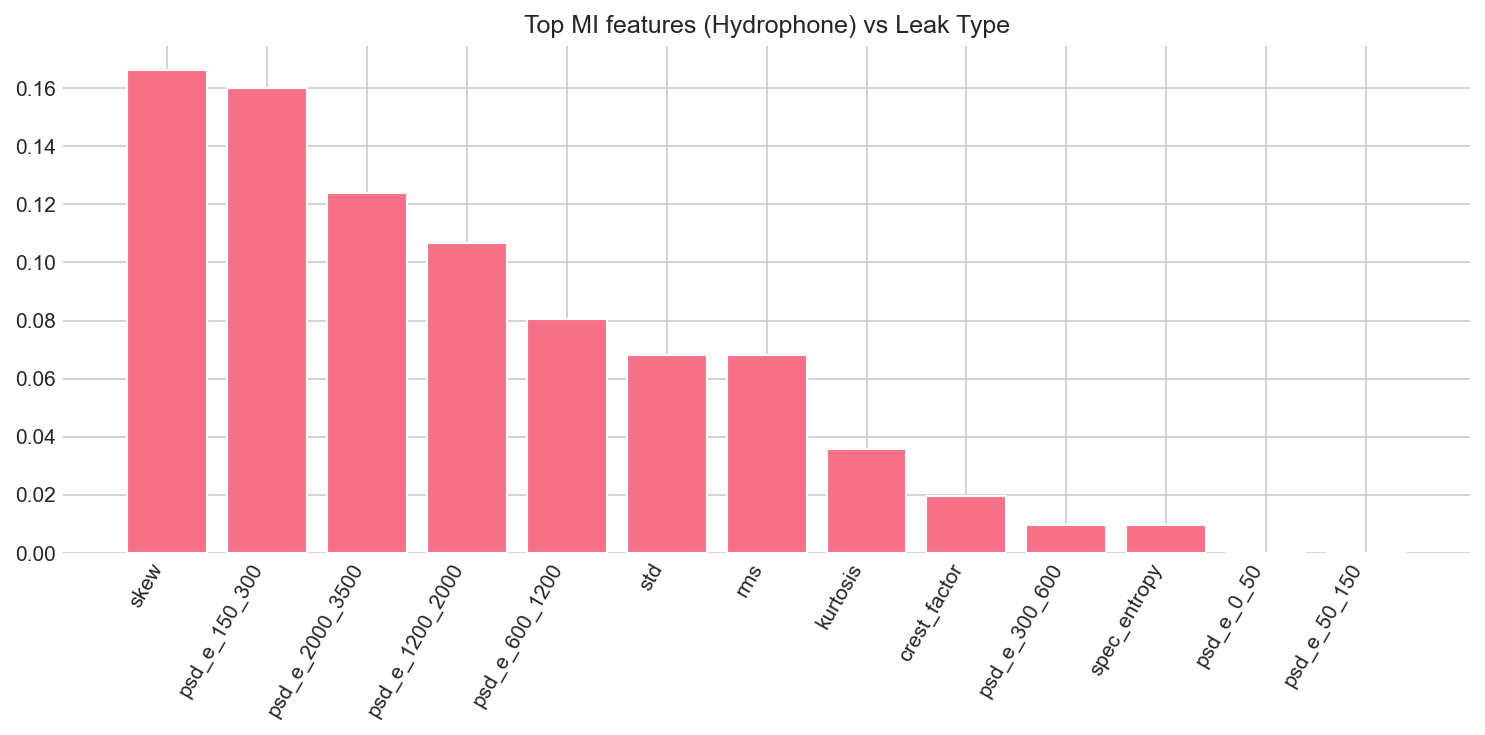

In [76]:
X = hyd_feat[[c for c in hyd_feat.columns if c.startswith(("rms","std","kurtosis","skew","crest_factor","psd_e_","spec_entropy"))]].values
y = hyd_feat["leak"].values

# encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# scale features
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

mi = mutual_info_classif(Xz, y_enc, discrete_features=False, random_state=0)
mi_df = pd.DataFrame({"feature": hyd_feat.columns[[hyd_feat.columns.get_loc(c) for c in hyd_feat.columns if c.startswith(("rms","std","kurtosis","skew","crest_factor","psd_e_","spec_entropy"))]] if False else []})

# easier: just reconstruct feature names
feature_cols = [c for c in hyd_feat.columns if c.startswith(("rms","std","kurtosis","skew","crest_factor","psd_e_","spec_entropy"))]
mi_df = pd.DataFrame({"feature": feature_cols, "MI(leak)": mi}).sort_values("MI(leak)", ascending=False)

display(mi_df.head(20))

plt.figure(figsize=(10,5))
plt.bar(mi_df["feature"].head(15), mi_df["MI(leak)"].head(15))
plt.xticks(rotation=60, ha="right")
plt.title("Top MI features (Hydrophone) vs Leak Type")
plt.tight_layout()
plt.show()


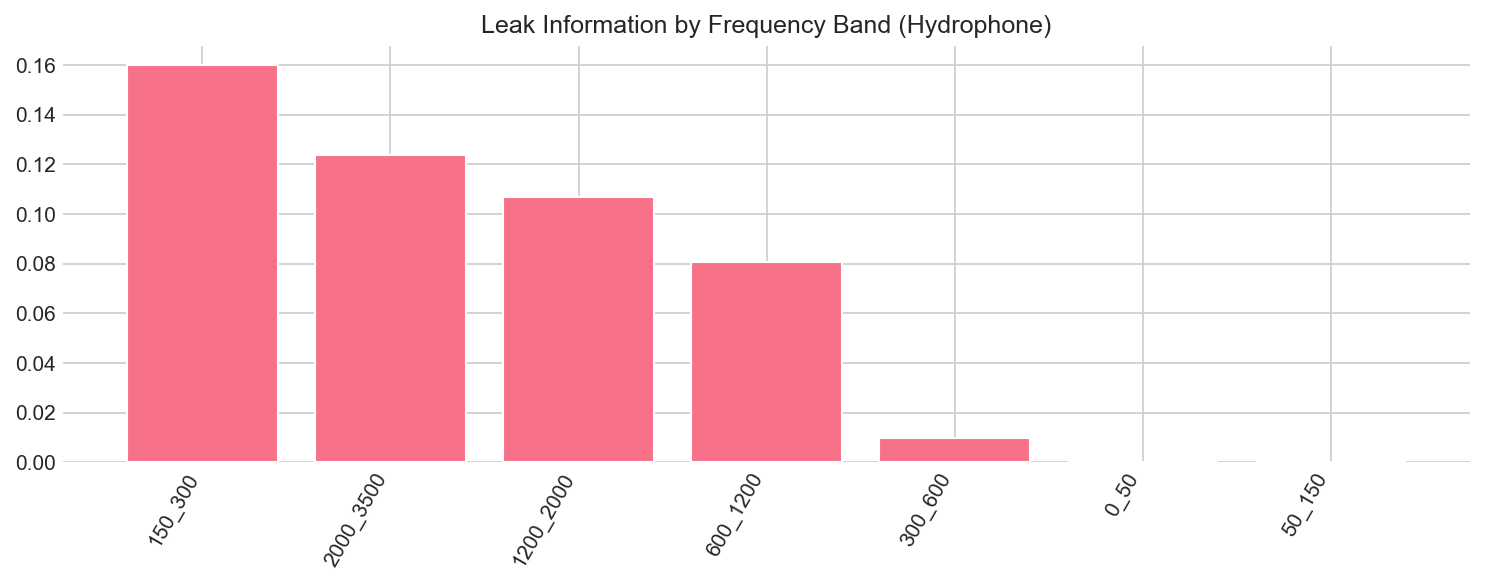

In [77]:
band_mi = mi_df[mi_df["feature"].str.startswith("psd_e_")].copy()
band_mi["band"] = band_mi["feature"].str.replace("psd_e_", "", regex=False)

plt.figure(figsize=(10,4))
plt.bar(band_mi["band"], band_mi["MI(leak)"])
plt.xticks(rotation=60, ha="right")
plt.title("Leak Information by Frequency Band (Hydrophone)")
plt.tight_layout()
plt.show()


In [78]:
def infer_fs_from_csv(path: str) -> Optional[int]:
    dfc = pd.read_csv(path)
    numeric_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) < 2:
        return None

    # find a likely time column
    for c in numeric_cols:
        t = dfc[c].values
        if np.all(np.diff(t) > 0) and (t[-1] - t[0]) > 1.0:
            dt = np.median(np.diff(t))
            if dt > 0:
                return int(round(1.0 / dt))
    return None


In [79]:
def build_feature_table(df_sub: pd.DataFrame, bands: List[Tuple[float,float]], default_band=None) -> pd.DataFrame:
    rows = []
    for _, row in df_sub.iterrows():
        x, fs = load_signal(row)

        # infer fs for CSV if possible
        if fs <= 0 and row["ext"] == ".csv":
            fs_inf = infer_fs_from_csv(row["path"])
            fs = fs_inf if fs_inf else -1

        x = preprocess(x, fs=fs if fs > 0 else 1, detrend=True, normalize=True, band=default_band)

        feats = {}
        feats.update(time_features(x))

        if fs > 0 and bands:
            feats.update(psd_band_energies(x, fs, bands))
            feats["spec_entropy"] = spectral_entropy(x, fs)
        else:
            feats["spec_entropy"] = np.nan

        rows.append({**row.to_dict(), "fs": fs, **feats})

    return pd.DataFrame(rows)


In [80]:
acc_df = df[df["sensor_type"] == "A"].copy().reset_index(drop=True)
pres_df = df[df["sensor_type"] == "P"].copy().reset_index(drop=True)

# You can adjust bands once we confirm Fs for these sensors.
BANDS_GENERIC = [(0,10),(10,30),(30,60),(60,120),(120,250),(250,500),(500,1000)]

acc_feat  = build_feature_table(acc_df, BANDS_GENERIC, default_band=None)
pres_feat = build_feature_table(pres_df, BANDS_GENERIC, default_band=None)

print("Accelerometer features:", acc_feat.shape)
print("Pressure features:", pres_feat.shape)

display(acc_feat.head())
display(pres_feat.head())


Accelerometer features: (60, 23)
Pressure features: (60, 23)


,path,topology,leak,flow,sensor_type,sensor_id,noise,ext,error,fs,...,skew,crest_factor,psd_e_0_10,psd_e_10_30,psd_e_30_60,psd_e_60_120,psd_e_120_250,psd_e_250_500,psd_e_500_1000,spec_entropy
0,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,A,1,NA,.csv,NaN,25602,...,0.010029,5.401472,0.000066,0.003160,0.031568,0.189397,0.264240,0.070594,0.152991,4.971326
1,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,A,2,NA,.csv,NaN,25602,...,-0.023204,4.506999,0.000570,0.000890,0.002392,0.161330,0.633027,0.074336,0.003116,3.659024
2,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,A,1,NA,.csv,NaN,25602,...,0.000385,5.214032,0.000040,0.002583,0.022727,0.052794,0.105425,0.100291,0.542173,4.896308
3,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,A,2,NA,.csv,NaN,25602,...,-0.627420,5.486768,0.004417,0.009345,0.006685,0.151569,0.299463,0.471311,0.003201,3.786376
4,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,A,1,NA,.csv,NaN,25602,...,-0.015660,4.786232,0.000392,0.020405,0.108816,0.160561,0.510048,0.053354,0.005262,3.403042


,path,topology,leak,flow,sensor_type,sensor_id,noise,ext,error,fs,...,skew,crest_factor,psd_e_0_10,psd_e_10_30,psd_e_30_60,psd_e_60_120,psd_e_120_250,psd_e_250_500,psd_e_500_1000,spec_entropy
0,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,P,1,NA,.csv,NaN,25602,...,0.026043,4.241983,0.000908,0.004279,0.011292,0.407561,0.440936,0.059702,0.004041,2.942006
1,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.18 LPS,P,2,NA,.csv,NaN,25602,...,-0.034160,2.909362,0.289341,0.236691,0.013091,0.003456,0.003239,0.000563,0.000769,1.491817
2,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,P,1,NA,.csv,NaN,25602,...,-0.000682,4.273847,0.000872,0.002976,0.005680,0.223675,0.346029,0.390455,0.011493,3.412198
3,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,0.47 LPS,P,2,NA,.csv,NaN,25602,...,-0.120410,3.848096,0.244446,0.305557,0.013642,0.003894,0.002626,0.000843,0.000473,1.554394
4,E:\Upwork Project\AI_Leak_Detection_Project\da...,BR,CC,ND,P,1,NA,.csv,NaN,25602,...,-0.046071,3.928777,0.001734,0.002302,0.016173,0.142413,0.327421,0.436771,0.007140,3.406260


In [81]:
def mi_summary(feat_df: pd.DataFrame, label_col="leak") -> pd.DataFrame:
    feature_cols = [c for c in feat_df.columns if c.startswith(("rms","std","kurtosis","skew","crest_factor","psd_e_","spec_entropy"))]
    feat_df = feat_df.dropna(subset=[label_col]).copy()

    X = feat_df[feature_cols].fillna(0).values
    y = LabelEncoder().fit_transform(feat_df[label_col].values)

    Xz = StandardScaler().fit_transform(X)
    mi = mutual_info_classif(Xz, y, discrete_features=False, random_state=0)

    out = pd.DataFrame({"feature": feature_cols, "MI": mi}).sort_values("MI", ascending=False)
    return out

mi_h = mi_summary(hyd_feat)
mi_a = mi_summary(acc_feat)
mi_p = mi_summary(pres_feat)

print("Top MI (Hydrophone):")
display(mi_h.head(10))
print("Top MI (Accelerometer):")
display(mi_a.head(10))
print("Top MI (Pressure):")
display(mi_p.head(10))


Top MI (Hydrophone):


,feature,MI
3,skew,0.166352
7,psd_e_150_300,0.159895
11,psd_e_2000_3500,0.123980
10,psd_e_1200_2000,0.106745
9,psd_e_600_1200,0.080671
1,std,0.068251
0,rms,0.068251
2,kurtosis,0.035854
4,crest_factor,0.019536
8,psd_e_300_600,0.009740


Top MI (Accelerometer):


,feature,MI
3,skew,0.159763
12,spec_entropy,0.156764
0,rms,0.092838
6,psd_e_10_30,0.085268
8,psd_e_60_120,0.066969
11,psd_e_500_1000,0.065971
4,crest_factor,0.061993
10,psd_e_250_500,0.021409
9,psd_e_120_250,0.017961
1,std,0.014780


Top MI (Pressure):


,feature,MI
9,psd_e_120_250,0.184667
7,psd_e_30_60,0.152802
1,std,0.136652
2,kurtosis,0.048823
0,rms,0.031236
4,crest_factor,0.021962
10,psd_e_250_500,0.000267
3,skew,0.000000
5,psd_e_0_10,0.000000
8,psd_e_60_120,0.000000


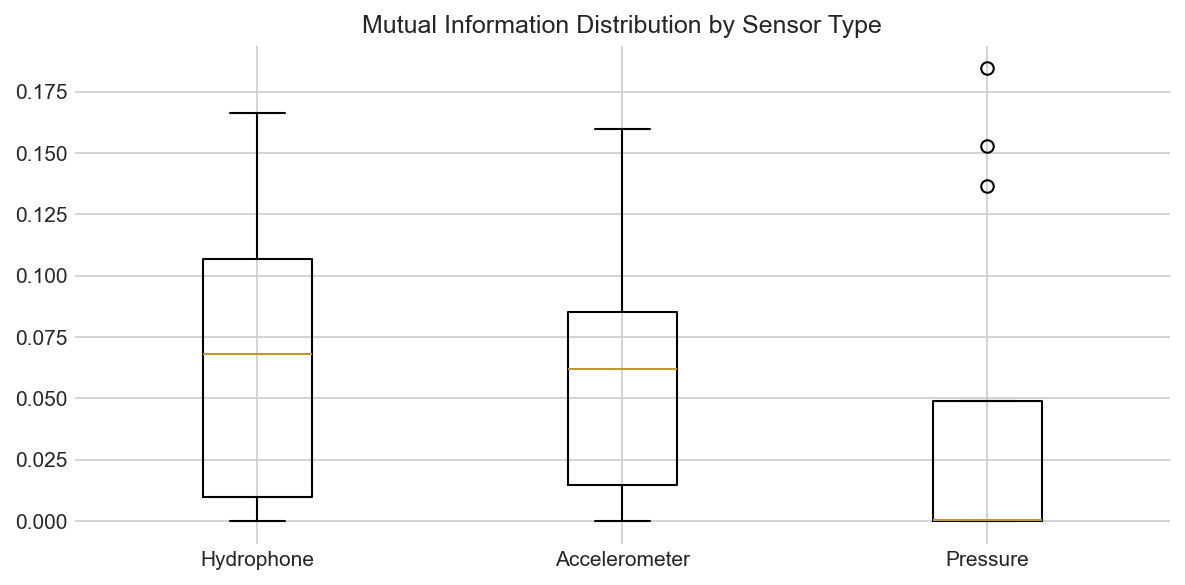

In [82]:
plt.figure(figsize=(8,4))
plt.boxplot([mi_h["MI"].values, mi_a["MI"].values, mi_p["MI"].values], labels=["Hydrophone","Accelerometer","Pressure"])
plt.title("Mutual Information Distribution by Sensor Type")
plt.tight_layout()
plt.show()


In [83]:
def inspect_csv(path: str, n=5):
    dfc = pd.read_csv(path)
    print("File:", path)
    print("Shape:", dfc.shape)
    print("Columns:", list(dfc.columns))
    print("\nHead:")
    display(dfc.head(n))
    print("\nNumeric columns:", dfc.select_dtypes(include=[np.number]).columns.tolist())

# pick one accel and one pressure sample you printed
rowA = df[df["sensor_type"]=="A"].iloc[0]
rowP = df[df["sensor_type"]=="P"].iloc[0]

inspect_csv(rowA["path"])
inspect_csv(rowP["path"])


File: E:\Upwork Project\AI_Leak_Detection_Project\data\raw\Accelerometer\Branched\Circumferential Crack\BR_CC_0.18 LPS_A1.csv
Shape: (923488, 2)
Columns: ['Sample', 'Value']

Head:


,Sample,Value
0,0.000000,0.004024
1,0.000039,0.003373
2,0.000078,0.002977
3,0.000117,0.001267
4,0.000156,0.000182



Numeric columns: ['Sample', 'Value']
File: E:\Upwork Project\AI_Leak_Detection_Project\data\raw\Dynamic Pressure Sensor\Branched\Circumferential Crack\BR_CC_0.18 LPS_P1.csv
Shape: (943716, 2)
Columns: ['Sample', 'Value']

Head:


,Sample,Value
0,0.000000,-5831.317138
1,0.000039,-5639.000792
2,0.000078,-5441.535304
3,0.000117,-5234.670590
4,0.000156,-5015.464283



Numeric columns: ['Sample', 'Value']


In [84]:
EXPECTED_DURATION_SEC = 30.0  # from dataset paper

def load_csv_time_and_signal(path: str):
    dfc = pd.read_csv(path)
    num = dfc.select_dtypes(include=[np.number]).copy()
    if num.shape[1] == 0:
        raise ValueError("No numeric columns")

    # Try detect time column: monotonic increasing and spans > 1 sec
    time_col = None
    for c in num.columns:
        v = num[c].values
        if np.all(np.diff(v) > 0) and (v[-1] - v[0]) > 1.0:
            time_col = c
            break

    if time_col is not None:
        t = num[time_col].values.astype(float)
        # choose a signal col different from time
        sig_cols = [c for c in num.columns if c != time_col]
        if len(sig_cols) == 0:
            # time only? unlikely, but handle
            x = dfc.iloc[:, -1].values.astype(float)
        else:
            x = num[sig_cols[0]].values.astype(float)
        return t, x, time_col, sig_cols[0] if len(sig_cols) else None

    # No time column found
    return None, num.iloc[:, 0].values.astype(float), None, num.columns[0]

def infer_fs_csv(path: str) -> Tuple[int, str]:
    t, x, time_col, sig_col = load_csv_time_and_signal(path)

    # Method 1: time column
    if t is not None:
        dt = np.median(np.diff(t))
        fs = int(round(1.0 / dt))
        return fs, f"time_col={time_col}, sig_col={sig_col}"

    # Method 2: expected duration
    fs = int(round(len(x) / EXPECTED_DURATION_SEC))
    return fs, f"duration_based({EXPECTED_DURATION_SEC}s), sig_col={sig_col}"

fsA, howA = infer_fs_csv(rowA["path"])
fsP, howP = infer_fs_csv(rowP["path"])

print("Accel Fs:", fsA, howA)
print("Press Fs:", fsP, howP)


Accel Fs: 25602 time_col=Sample, sig_col=Value
Press Fs: 25602 time_col=Sample, sig_col=Value


In [85]:
def duration_sec(n: int, fs: int) -> float:
    return n / fs

# hydrophone reported
durH = duration_sec(642920, 8000)
print("Hydrophone duration (sec):", durH)

print("Accelerometer duration (sec):", duration_sec(923488, fsA))
print("Pressure duration (sec):", duration_sec(943716, fsP))


Hydrophone duration (sec): 80.365
Accelerometer duration (sec): 36.070931958440745
Pressure duration (sec): 36.86102648230607


In [86]:
def raw_len_seconds(path: str, dtype, fs=FS_HYD):
    x = np.fromfile(path, dtype=dtype)
    return len(x), len(x)/fs

rowH = df[df["sensor_type"]=="H"].iloc[0]
hp = rowH["path"]

for dt in [np.int16, np.int32, np.float32]:
    n, d = raw_len_seconds(hp, dt)
    print(f"dtype={dt.__name__:>7}  n={n:<10}  duration={d:.2f} sec")


dtype=  int16  n=642920      duration=80.36 sec
dtype=  int32  n=321460      duration=40.18 sec
dtype=float32  n=321460      duration=40.18 sec


In [87]:
# choose dtype based on the test above
HYD_DTYPE = np.int16  # change this if needed

def load_raw_hydrophone(path: str, dtype=HYD_DTYPE) -> np.ndarray:
    data = np.fromfile(path, dtype=dtype).astype(np.float32)
    if np.max(np.abs(data)) > 0:
        data /= np.max(np.abs(data))
    return data


In [88]:
TARGET_DURATION = 30.0  # seconds (as per dataset paper)
FS_AP = 25602          # Accelerometer & Pressure
FS_H  = 8000           # Hydrophone
HYD_DTYPE = np.int32   # confirmed


In [89]:
def center_crop(x: np.ndarray, fs: int, duration_sec: float) -> np.ndarray:
    n_target = int(fs * duration_sec)
    if len(x) < n_target:
        raise ValueError("Signal shorter than target duration")

    start = (len(x) - n_target) // 2
    end = start + n_target
    return x[start:end]


In [90]:
def load_signal_final(row: pd.Series) -> Tuple[np.ndarray, int]:
    if row["sensor_type"] in ["A", "P"]:
        dfc = pd.read_csv(row["path"])
        x = dfc["Value"].astype(float).values
        fs = FS_AP

    elif row["sensor_type"] == "H":
        x = np.fromfile(row["path"], dtype=HYD_DTYPE).astype(np.float32)
        if np.max(np.abs(x)) > 0:
            x /= np.max(np.abs(x))
        fs = FS_H

    else:
        raise ValueError("Unknown sensor type")

    # Centered 30 s crop
    x = center_crop(x, fs, TARGET_DURATION)
    return x, fs


In [91]:
for stype in ["A", "P", "H"]:
    r = df[df["sensor_type"] == stype].iloc[0]
    x, fs = load_signal_final(r)
    print(
        stype,
        "len:", len(x),
        "fs:", fs,
        "duration:", len(x)/fs,
        "meta:", r[["topology","leak","flow","noise","sensor_id"]].to_dict()
    )


A len: 768060 fs: 25602 duration: 30.0 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'NA', 'sensor_id': '1'}
P len: 768060 fs: 25602 duration: 30.0 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'NA', 'sensor_id': '1'}
H len: 240000 fs: 8000 duration: 30.0 meta: {'topology': 'BR', 'leak': 'CC', 'flow': '0.18 LPS', 'noise': 'N', 'sensor_id': '1'}


In [92]:
def preprocess(x: np.ndarray, fs: int) -> np.ndarray:
    x = signal.detrend(x)
    x = (x - np.mean(x)) / (np.std(x) + 1e-9)
    return x


In [93]:
BANDS_H = [(0,50),(50,150),(150,300),(300,600),(600,1200),(1200,2000),(2000,3500)]
BANDS_AP = [(0,10),(10,30),(30,60),(60,120),(120,250),(250,500),(500,1000)]


In [94]:
def extract_features(x: np.ndarray, fs: int, bands):
    feats = {}

    # Time-domain
    feats["rms"] = np.sqrt(np.mean(x**2))
    feats["std"] = np.std(x)
    feats["kurtosis"] = stats.kurtosis(x, fisher=False)
    feats["skew"] = stats.skew(x)
    feats["crest"] = np.max(np.abs(x)) / (feats["rms"] + 1e-9)

    # Frequency-domain
    f, Pxx = signal.welch(x, fs=fs, nperseg=8192)
    Pxx /= np.trapz(Pxx, f) + 1e-12

    for lo, hi in bands:
        m = (f >= lo) & (f < hi)
        feats[f"E_{lo}_{hi}"] = np.trapz(Pxx[m], f[m])

    feats["spec_entropy"] = -np.sum(Pxx * np.log(Pxx + 1e-12))
    return feats


In [95]:
def build_table(df_sub, bands):
    rows = []
    for _, row in df_sub.iterrows():
        x, fs = load_signal_final(row)
        x = preprocess(x, fs)
        feats = extract_features(x, fs, bands)
        rows.append({**row.to_dict(), **feats})
    return pd.DataFrame(rows)

hyd_feat  = build_table(df[df.sensor_type=="H"], BANDS_H)
acc_feat  = build_table(df[df.sensor_type=="A"], BANDS_AP)
pres_feat = build_table(df[df.sensor_type=="P"], BANDS_AP)


In [96]:
def compute_mi(df_feat, label="leak"):
    feat_cols = [c for c in df_feat.columns if c.startswith(("rms","std","kurtosis","skew","crest","E_","spec_entropy"))]
    X = StandardScaler().fit_transform(df_feat[feat_cols].values)
    y = LabelEncoder().fit_transform(df_feat[label].values)
    mi = mutual_info_classif(X, y, random_state=0)
    return pd.DataFrame({"feature": feat_cols, "MI": mi}).sort_values("MI", ascending=False)

mi_H = compute_mi(hyd_feat)
mi_A = compute_mi(acc_feat)
mi_P = compute_mi(pres_feat)

display(mi_H.head(10))
display(mi_A.head(10))
display(mi_P.head(10))


,feature,MI
2,kurtosis,0.138013
7,E_150_300,0.108231
4,crest,0.103146
8,E_300_600,0.053431
1,std,0.044620
0,rms,0.022715
10,E_1200_2000,0.012780
12,spec_entropy,0.011668
3,skew,0.000000
5,E_0_50,0.000000


,feature,MI
12,spec_entropy,0.210127
9,E_120_250,0.172850
6,E_10_30,0.161059
8,E_60_120,0.159531
10,E_250_500,0.108788
11,E_500_1000,0.076424
3,skew,0.075219
1,std,0.062028
0,rms,0.062028
2,kurtosis,0.059085


,feature,MI
2,kurtosis,0.154943
9,E_120_250,0.135148
0,rms,0.102395
1,std,0.102395
3,skew,0.029405
4,crest,0.000000
5,E_0_10,0.000000
7,E_30_60,0.000000
6,E_10_30,0.000000
8,E_60_120,0.000000


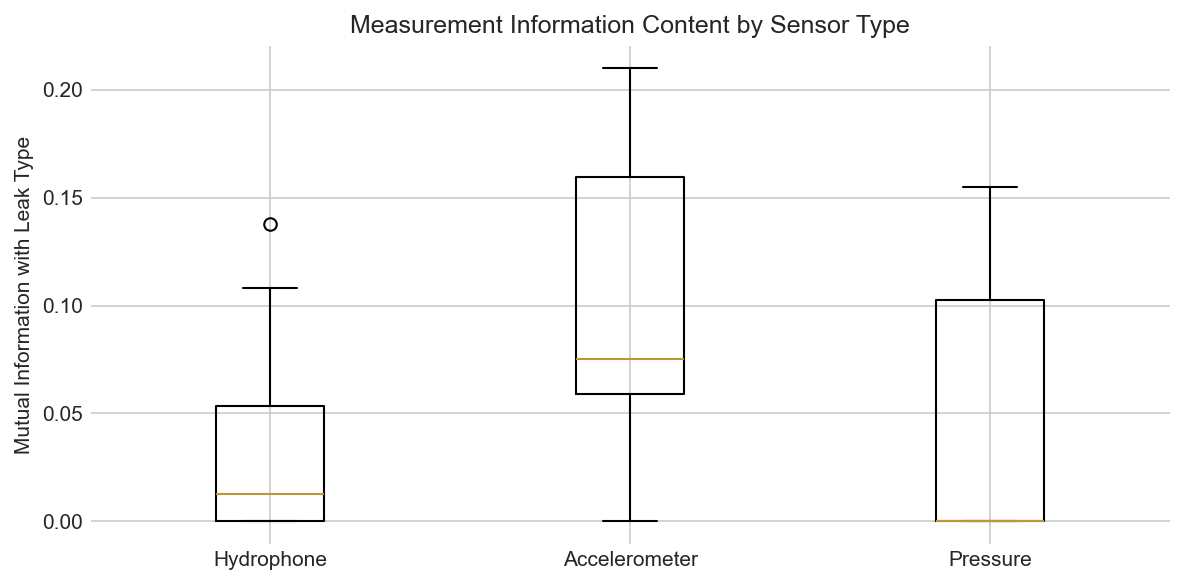

In [97]:
plt.figure(figsize=(8,4))
plt.boxplot([mi_H.MI, mi_A.MI, mi_P.MI], labels=["Hydrophone","Accelerometer","Pressure"])
plt.ylabel("Mutual Information with Leak Type")
plt.title("Measurement Information Content by Sensor Type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [98]:
def feature_cols(df_feat):
    return [c for c in df_feat.columns if c.startswith(("rms","std","kurtosis","skew","crest","E_","spec_entropy"))]

def clean_feat(df_feat):
    cols = ["topology","leak","flow","noise","sensor_type","sensor_id"] + feature_cols(df_feat)
    out = df_feat[cols].copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out


In [99]:
def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    sp = np.sqrt(((na-1)*sa + (nb-1)*sb) / (na+nb-2) + 1e-12)
    return (np.mean(a) - np.mean(b)) / (sp + 1e-12)

def topology_effect_table(df_feat):
    dfc = clean_feat(df_feat)
    feats = feature_cols(dfc)

    rows = []
    for f in feats:
        br = dfc[dfc["topology"]=="BR"][f].values
        lo = dfc[dfc["topology"]=="LO"][f].values
        if len(br) < 5 or len(lo) < 5:
            continue
        d = cohens_d(br, lo)
        rows.append({"feature": f, "cohens_d(BR-LO)": float(d), "abs_d": float(abs(d))})

    return pd.DataFrame(rows).sort_values("abs_d", ascending=True)

topo_H = topology_effect_table(hyd_feat)
topo_A = topology_effect_table(acc_feat)
topo_P = topology_effect_table(pres_feat)

print("Most topology-invariant features (Hydrophone):")
display(topo_H.head(15))
print("Most topology-invariant features (Accelerometer):")
display(topo_A.head(15))
print("Most topology-invariant features (Pressure):")
display(topo_P.head(15))


Most topology-invariant features (Hydrophone):


,feature,cohens_d(BR-LO),abs_d
0,rms,0.000000,0.000000
1,std,0.000000,0.000000
4,crest,0.065566,0.065566
3,skew,-0.120017,0.120017
8,E_300_600,0.198463,0.198463
2,kurtosis,0.250543,0.250543
9,E_600_1200,0.420074,0.420074
11,E_2000_3500,0.424575,0.424575
10,E_1200_2000,0.440582,0.440582
7,E_150_300,-0.660982,0.660982


Most topology-invariant features (Accelerometer):


,feature,cohens_d(BR-LO),abs_d
11,E_500_1000,0.060678,0.060678
3,skew,-0.178623,0.178623
12,spec_entropy,-0.249728,0.249728
5,E_0_10,0.269368,0.269368
10,E_250_500,0.276281,0.276281
2,kurtosis,-0.284996,0.284996
4,crest,0.340117,0.340117
7,E_30_60,-0.418584,0.418584
1,std,0.437723,0.437723
0,rms,0.437723,0.437723


Most topology-invariant features (Pressure):


,feature,cohens_d(BR-LO),abs_d
0,rms,0.000001,0.000001
1,std,0.000001,0.000001
8,E_60_120,-0.054169,0.054169
6,E_10_30,-0.203257,0.203257
3,skew,0.241086,0.241086
2,kurtosis,-0.272985,0.272985
9,E_120_250,0.407347,0.407347
4,crest,-0.436255,0.436255
5,E_0_10,0.569226,0.569226
12,spec_entropy,-0.748218,0.748218


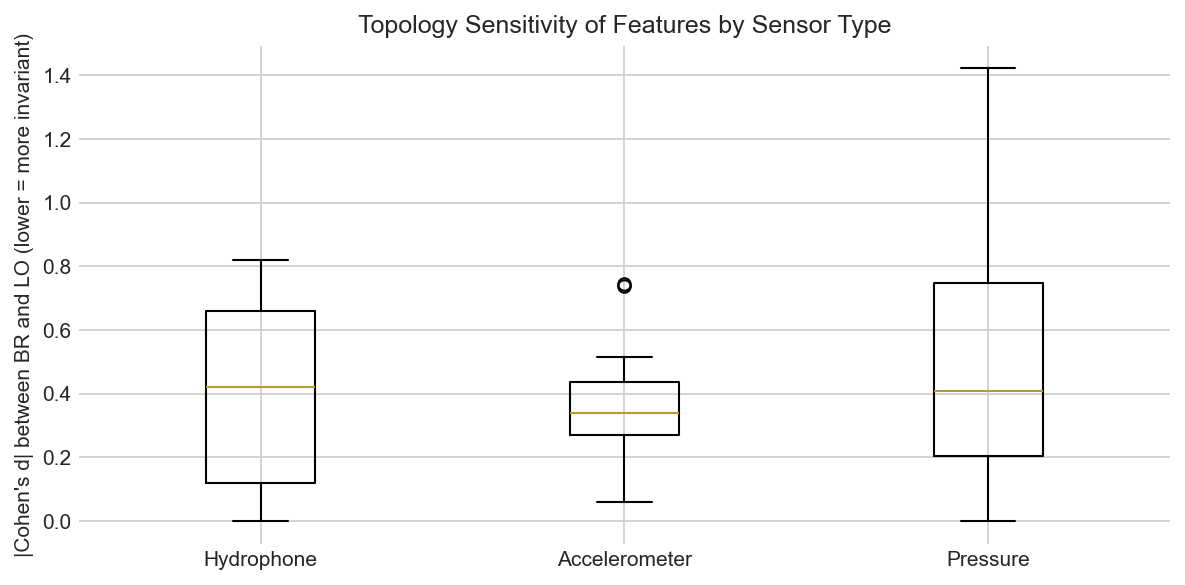

In [100]:
plt.figure(figsize=(8,4))
plt.boxplot([topo_H["abs_d"], topo_A["abs_d"], topo_P["abs_d"]],
            labels=["Hydrophone","Accelerometer","Pressure"])
plt.ylabel("|Cohen's d| between BR and LO (lower = more invariant)")
plt.title("Topology Sensitivity of Features by Sensor Type")
plt.grid(True)
plt.tight_layout()
plt.show()


Hydrophone  BR->LO  Acc=0.075  MacroF1=0.067


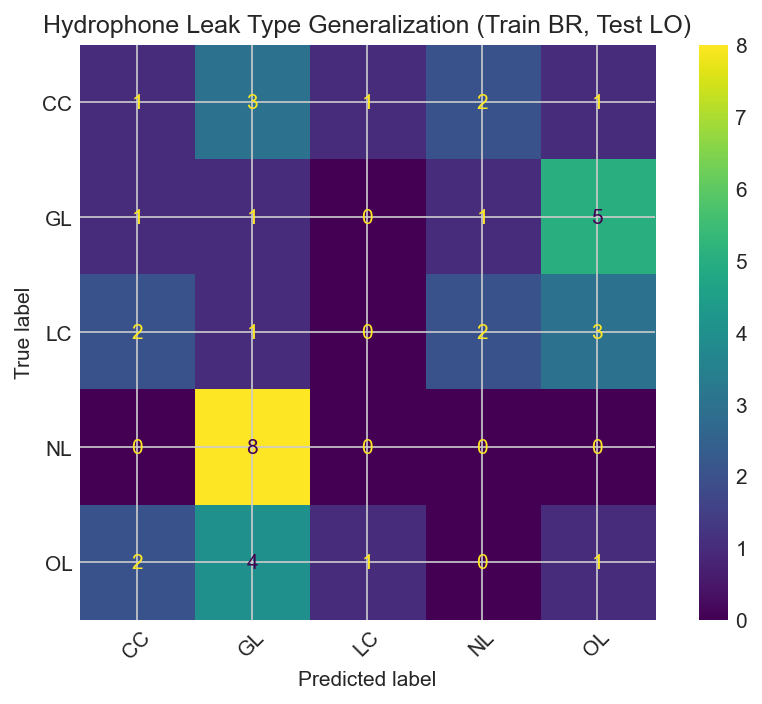

Accelerometer  BR->LO  Acc=0.100  MacroF1=0.087


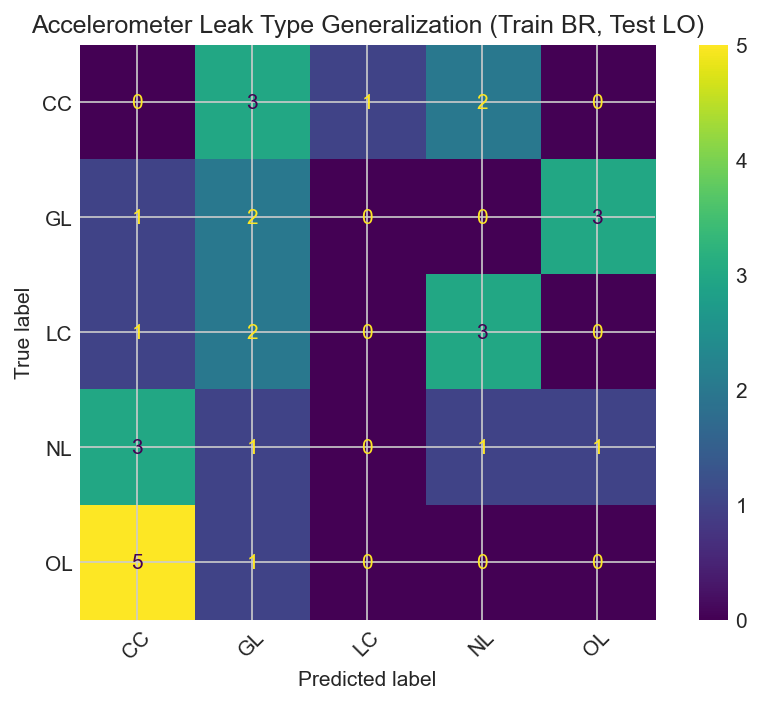

Pressure  BR->LO  Acc=0.167  MacroF1=0.099


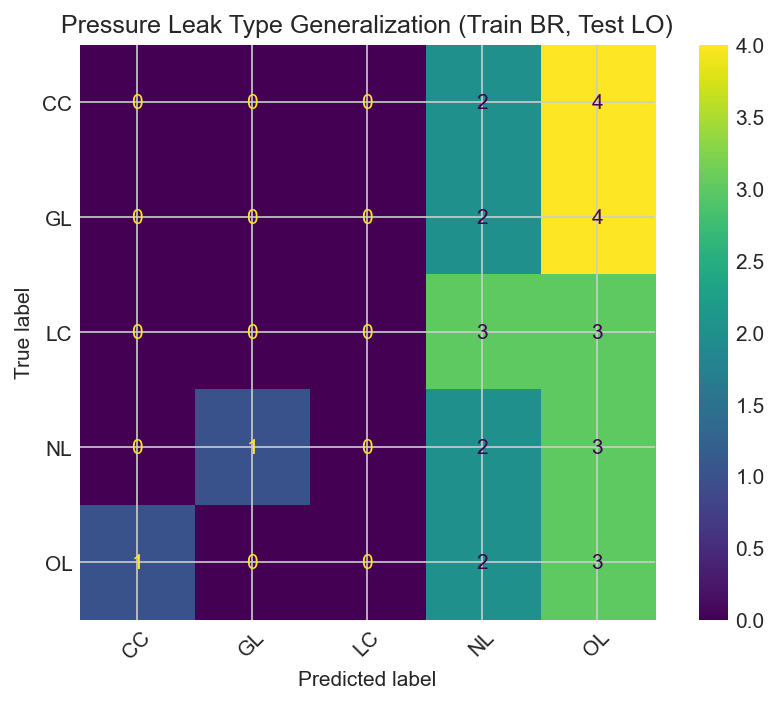

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def topo_generalization(df_feat, sensor_name=""):
    dfc = clean_feat(df_feat)
    feats = feature_cols(dfc)

    train = dfc[dfc["topology"]=="BR"].copy()
    test  = dfc[dfc["topology"]=="LO"].copy()

    Xtr = StandardScaler().fit_transform(train[feats].values)
    Xte = StandardScaler().fit(train[feats].values).transform(test[feats].values)

    le = LabelEncoder()
    ytr = le.fit_transform(train["leak"].values)
    yte = le.transform(test["leak"].values)

    clf = LogisticRegression(max_iter=2000, multi_class="auto")
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    acc = accuracy_score(yte, pred)
    f1  = f1_score(yte, pred, average="macro")

    print(f"{sensor_name}  BR->LO  Acc={acc:.3f}  MacroF1={f1:.3f}")

    cm = confusion_matrix(yte, pred, labels=np.arange(len(le.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(xticks_rotation=45)
    plt.title(f"{sensor_name} Leak Type Generalization (Train BR, Test LO)")
    plt.tight_layout()
    plt.show()

topo_generalization(hyd_feat, "Hydrophone")
topo_generalization(acc_feat, "Accelerometer")
topo_generalization(pres_feat, "Pressure")


In [102]:
hyd_c = clean_feat(hyd_feat)
hyd_c = hyd_c[hyd_c["noise"].isin(["N","NN"])].copy()

feats = feature_cols(hyd_c)

# Compare spectral entropy & band energies shift under noise
noise_stats = []
for f in feats:
    a = hyd_c[hyd_c["noise"]=="NN"][f].values
    b = hyd_c[hyd_c["noise"]=="N"][f].values
    if len(a) < 5 or len(b) < 5:
        continue
    d = cohens_d(a, b)  # NN - N
    noise_stats.append({"feature": f, "cohens_d(NN-N)": float(d), "abs_d": float(abs(d))})

noise_tbl = pd.DataFrame(noise_stats).sort_values("abs_d", ascending=False)

print("Most noise-sensitive features (Hydrophone):")
display(noise_tbl.head(20))


Most noise-sensitive features (Hydrophone):


,feature,cohens_d(NN-N),abs_d
7,E_150_300,-0.384840,0.384840
12,spec_entropy,-0.282055,0.282055
10,E_1200_2000,-0.258572,0.258572
8,E_300_600,-0.191883,0.191883
4,crest,-0.161169,0.161169
6,E_50_150,0.156575,0.156575
5,E_0_50,-0.150960,0.150960
2,kurtosis,-0.118971,0.118971
9,E_600_1200,0.107497,0.107497
3,skew,0.102191,0.102191


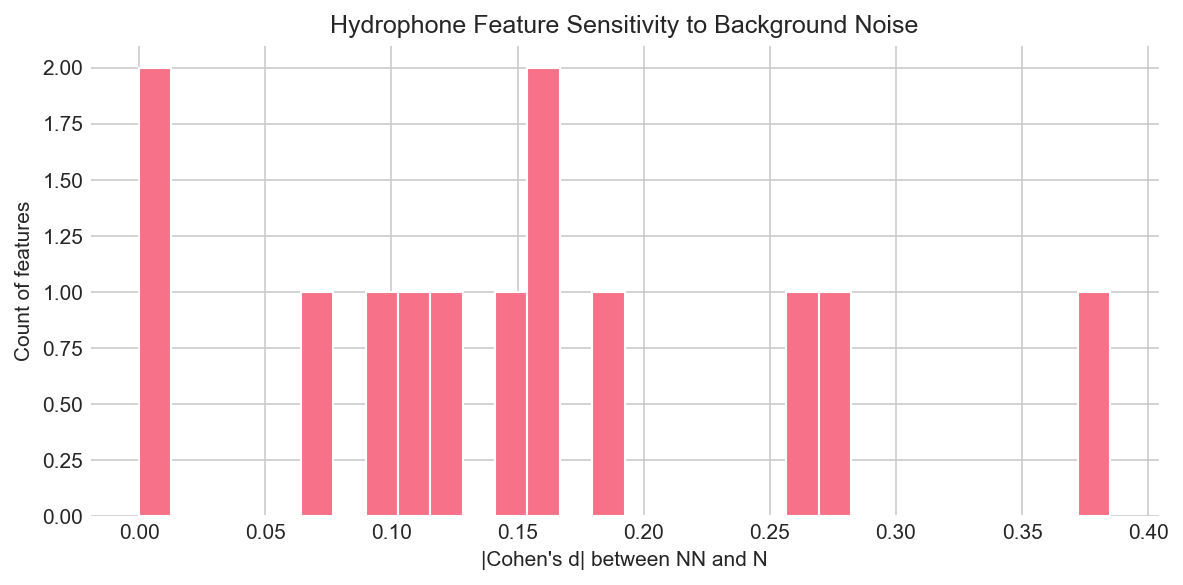

In [103]:
plt.figure(figsize=(8,4))
plt.hist(noise_tbl["abs_d"], bins=30)
plt.xlabel("|Cohen's d| between NN and N")
plt.ylabel("Count of features")
plt.title("Hydrophone Feature Sensitivity to Background Noise")
plt.tight_layout()
plt.show()


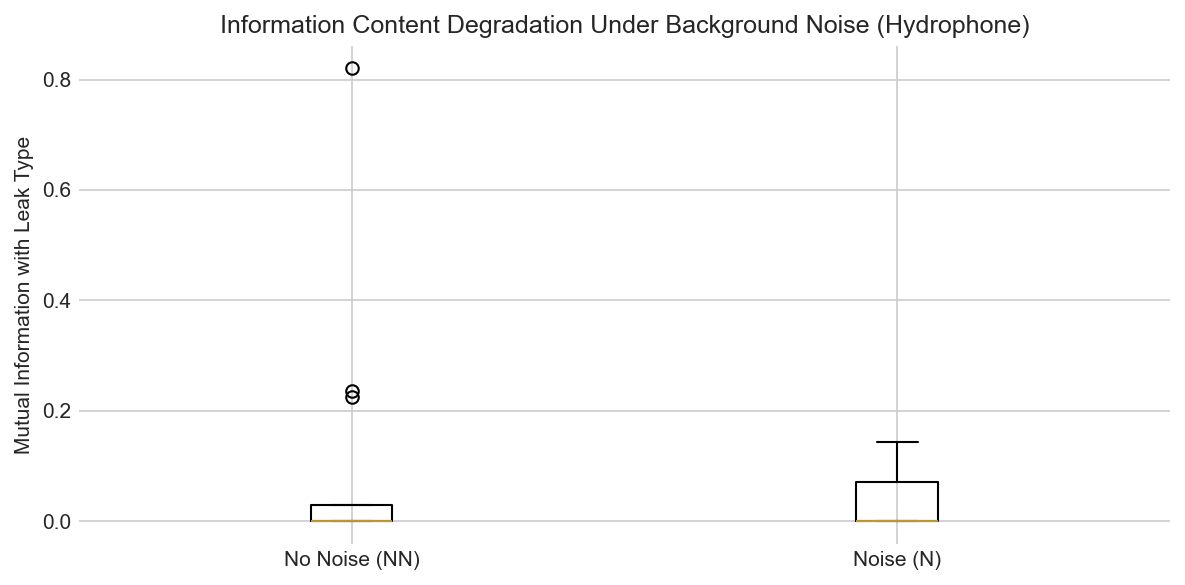

Top MI features (NN):


,feature,MI
1,std,0.820762
2,kurtosis,0.236135
4,crest,0.224128
12,spec_entropy,0.029198
0,rms,0.000000
3,skew,0.000000
5,E_0_50,0.000000
7,E_150_300,0.000000
6,E_50_150,0.000000
8,E_300_600,0.000000


Top MI features (N):


,feature,MI
2,kurtosis,0.142902
4,crest,0.089684
10,E_1200_2000,0.079919
7,E_150_300,0.070454
0,rms,0.000000
3,skew,0.000000
1,std,0.000000
6,E_50_150,0.000000
5,E_0_50,0.000000
8,E_300_600,0.000000


In [104]:
def mi_by_subset(df_feat, subset_mask, label="leak"):
    d = clean_feat(df_feat)[subset_mask].copy()
    feats = feature_cols(d)
    X = StandardScaler().fit_transform(d[feats].values)
    y = LabelEncoder().fit_transform(d[label].values)
    mi = mutual_info_classif(X, y, random_state=0)
    return pd.DataFrame({"feature": feats, "MI": mi}).sort_values("MI", ascending=False)

hyd_c = clean_feat(hyd_feat)
mi_NN = mi_by_subset(hyd_feat, (hyd_c["noise"]=="NN"), label="leak")
mi_N  = mi_by_subset(hyd_feat, (hyd_c["noise"]=="N"),  label="leak")

# Compare MI distributions
plt.figure(figsize=(8,4))
plt.boxplot([mi_NN["MI"], mi_N["MI"]], labels=["No Noise (NN)","Noise (N)"])
plt.ylabel("Mutual Information with Leak Type")
plt.title("Information Content Degradation Under Background Noise (Hydrophone)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Top MI features (NN):")
display(mi_NN.head(10))
print("Top MI features (N):")
display(mi_N.head(10))


In [105]:
def merge_mi_topology(mi_df, topo_df):
    out = mi_df.merge(topo_df, on="feature", how="inner")
    out["robust_score"] = out["MI"] / (out["abs_d"] + 1e-6)
    return out.sort_values("robust_score", ascending=False)

rob_H = merge_mi_topology(mi_H, topo_H)
rob_A = merge_mi_topology(mi_A, topo_A)
rob_P = merge_mi_topology(mi_P, topo_P)

print("Top ROBUST features (Hydrophone):")
display(rob_H.head(15))

print("Top ROBUST features (Accelerometer):")
display(rob_A.head(15))

print("Top ROBUST features (Pressure):")
display(rob_P.head(15))


Top ROBUST features (Hydrophone):


,feature,MI,cohens_d(BR-LO),abs_d,robust_score
4,std,0.044620,0.000000,0.000000,44619.577634
5,rms,0.022715,0.000000,0.000000,22715.259575
2,crest,0.103146,0.065566,0.065566,1.573134
0,kurtosis,0.138013,0.250543,0.250543,0.550854
3,E_300_600,0.053431,0.198463,0.198463,0.269221
1,E_150_300,0.108231,-0.660982,0.660982,0.163743
6,E_1200_2000,0.012780,0.440582,0.440582,0.029007
7,spec_entropy,0.011668,-0.818778,0.818778,0.014251
8,skew,0.000000,-0.120017,0.120017,0.000000
9,E_0_50,0.000000,0.700229,0.700229,0.000000


Top ROBUST features (Accelerometer):


,feature,MI,cohens_d(BR-LO),abs_d,robust_score
5,E_500_1000,0.076424,0.060678,0.060678,1.259476
0,spec_entropy,0.210127,-0.249728,0.249728,0.841421
6,skew,0.075219,-0.178623,0.178623,0.421103
4,E_250_500,0.108788,0.276281,0.276281,0.393756
1,E_120_250,0.172850,0.515376,0.515376,0.335385
2,E_10_30,0.161059,0.743436,0.743436,0.216642
3,E_60_120,0.159531,-0.737076,0.737076,0.216437
9,kurtosis,0.059085,-0.284996,0.284996,0.207319
7,std,0.062028,0.437723,0.437723,0.141705
8,rms,0.062028,0.437723,0.437723,0.141705


Top ROBUST features (Pressure):


,feature,MI,cohens_d(BR-LO),abs_d,robust_score
2,rms,0.102395,0.000001,0.000001,47113.104956
3,std,0.102395,0.000001,0.000001,47113.104956
0,kurtosis,0.154943,-0.272985,0.272985,0.567585
1,E_120_250,0.135148,0.407347,0.407347,0.331777
4,skew,0.029405,0.241086,0.241086,0.121968
5,crest,0.000000,-0.436255,0.436255,0.000000
6,E_0_10,0.000000,0.569226,0.569226,0.000000
7,E_30_60,0.000000,-1.422732,1.422732,0.000000
8,E_10_30,0.000000,-0.203257,0.203257,0.000000
9,E_60_120,0.000000,-0.054169,0.054169,0.000000


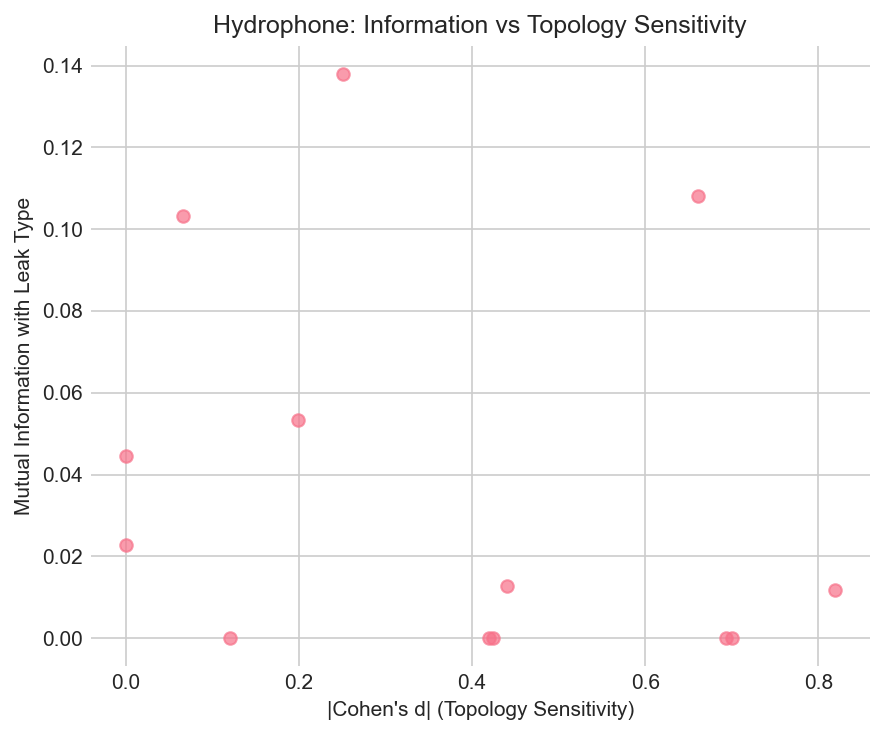

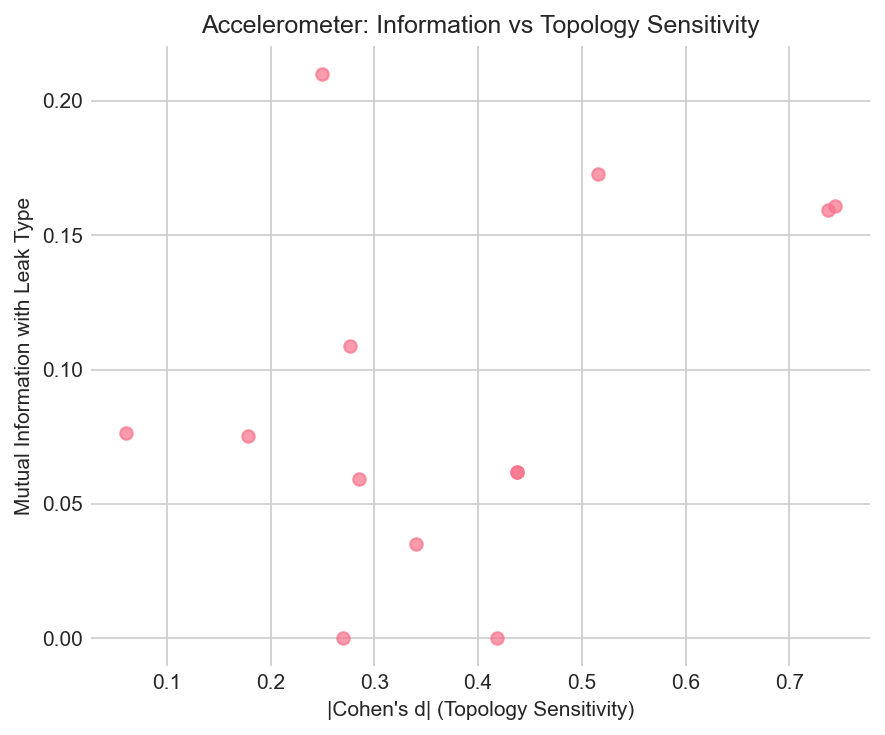

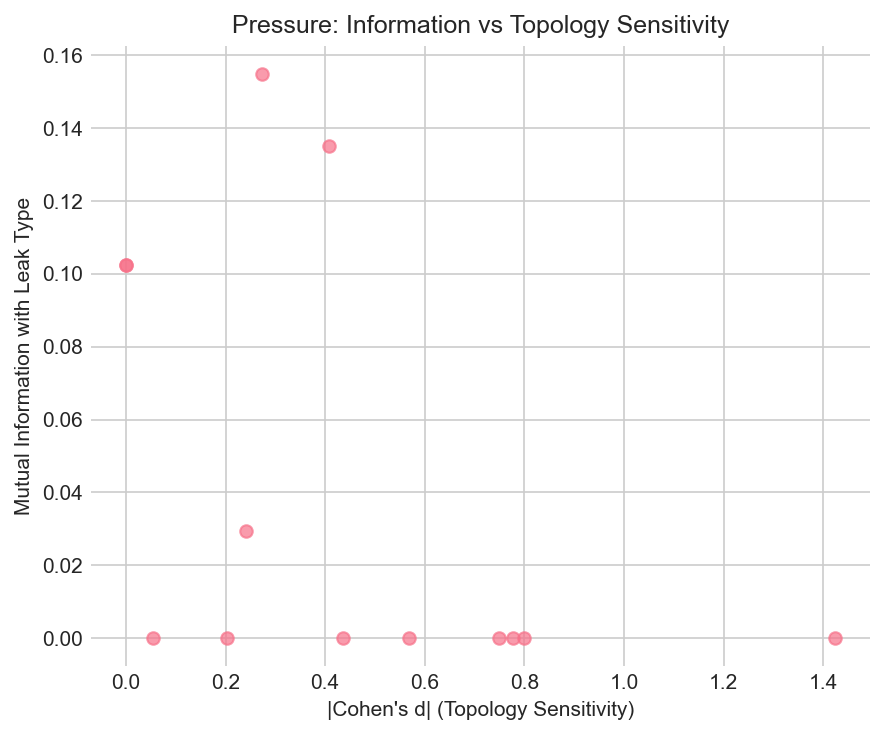

In [106]:
def plot_info_vs_topology(rob, title):
    plt.figure(figsize=(6,5))
    plt.scatter(rob["abs_d"], rob["MI"], alpha=0.7)
    plt.xlabel("|Cohen's d| (Topology Sensitivity)")
    plt.ylabel("Mutual Information with Leak Type")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_info_vs_topology(rob_H, "Hydrophone: Information vs Topology Sensitivity")
plot_info_vs_topology(rob_A, "Accelerometer: Information vs Topology Sensitivity")
plot_info_vs_topology(rob_P, "Pressure: Information vs Topology Sensitivity")


In [107]:
def topo_generalization_robust(df_feat, rob_df, sensor_name, top_k=10):
    dfc = clean_feat(df_feat)
    feats = rob_df.head(top_k)["feature"].tolist()

    train = dfc[dfc["topology"]=="BR"]
    test  = dfc[dfc["topology"]=="LO"]

    Xtr = StandardScaler().fit_transform(train[feats])
    Xte = StandardScaler().fit(train[feats]).transform(test[feats])

    ytr = LabelEncoder().fit_transform(train["leak"])
    yte = LabelEncoder().fit_transform(test["leak"])

    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    acc = accuracy_score(yte, pred)
    f1  = f1_score(yte, pred, average="macro")

    print(f"{sensor_name} (robust features)  Acc={acc:.3f}  MacroF1={f1:.3f}")

topo_generalization_robust(hyd_feat, rob_H, "Hydrophone")
topo_generalization_robust(acc_feat, rob_A, "Accelerometer")
topo_generalization_robust(pres_feat, rob_P, "Pressure")


Hydrophone (robust features)  Acc=0.125  MacroF1=0.134
Accelerometer (robust features)  Acc=0.167  MacroF1=0.128
Pressure (robust features)  Acc=0.200  MacroF1=0.159


In [ ]:
# ===========================
# DG-MCLR: FIXED VERSION
# ===========================
import os, re, glob, math, random, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, balanced_accuracy_score

warnings.filterwarnings("ignore")
torch.set_float32_matmul_precision("high")

# ---------------------------
# CONFIG
# ---------------------------
ROOT = Path(r"E:\Upwork Project\AI_Leak_Detection_Project\data\raw")
ACC_DIR  = ROOT / "Accelerometer"
PRES_DIR = ROOT / "Dynamic Pressure Sensor"
HYD_DIR  = ROOT / "Hydrophone"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

WIN_SEC = 2.0
HOP_SEC = 1.0
TARGET_FS_HYD = 8000
DOWNSAMPLE_HIGH_FS_TO = 8000

BATCH = 48
NUM_WORKERS = 0
EPOCHS_SSL = 20
EPOCHS_FT  = 15
LR_SSL = 3e-4
LR_FT  = 2e-4
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.2
LAMBDA_SSL_IN_FT = 0.2

EMB_DIM = 256
DROP = 0.1
DOMAIN_KEYS = ["noise", "flow", "topology"]

# ---------------------------
# Utility functions
# ---------------------------
def zscore(x: np.ndarray, eps=1e-8):
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + eps)

def resample_1d(x: np.ndarray, orig_fs: int, target_fs: int) -> np.ndarray:
    if orig_fs == target_fs:
        return x
    n = len(x)
    t = np.linspace(0, 1, n, endpoint=False)
    m = int(round(n * target_fs / orig_fs))
    tt = np.linspace(0, 1, m, endpoint=False)
    return np.interp(tt, t, x).astype(np.float32)

def random_time_mask(x: torch.Tensor, max_frac=0.1):
    T = x.shape[-1]
    w = int(T * random.uniform(0.0, max_frac))
    if w <= 1: return x
    s = random.randint(0, max(0, T-w))
    x = x.clone()
    x[..., s:s+w] = 0
    return x

def random_gain(x: torch.Tensor, db=6.0):
    g = 10 ** (random.uniform(-db, db) / 20.0)
    return x * g

def random_jitter(x: torch.Tensor, sigma=0.005):
    return x + sigma * torch.randn_like(x)

def augment_wave(x: torch.Tensor):
    if random.random() < 0.8: x = random_gain(x, db=4.0)
    if random.random() < 0.7: x = random_jitter(x, sigma=0.003)
    if random.random() < 0.5: x = random_time_mask(x, max_frac=0.08)
    return x

# ---------------------------
# Metadata parsing - FIXED
# ---------------------------
LEAK_TYPES = ["NL","OL","LC","CC","GL"]
TOPOLOGIES = ["LO","BR"]
NOISES = ["N","NN"]
FLOWS = ["ND","0.18","0.47","TR"]

def parse_metadata_from_filename(fp: Path):
    """
    Parse filenames like:
    - BR_CC_0.18 LPS_A1.csv  -> topo=BR, leak=CC, flow=0.18
    - BR_GL_ND_P1.csv        -> topo=BR, leak=GL, flow=ND
    - LO_NL_Transient_H1.raw -> topo=LO, leak=NL, flow=TR
    """
    name = fp.stem.upper()
    
    # Remove sensor IDs
    name_clean = re.sub(r"_(A|P|H)[12]$", "", name)
    name_clean = re.sub(r"_N_|_NN_", "_", name_clean)
    
    # Split by underscore to get tokens
    tokens = name_clean.split("_")
    
    # Extract leak type - check each token
    leak = None
    for token in tokens:
        if token in LEAK_TYPES:
            leak = token
            break
    
    # Extract topology - check each token
    topo = None
    for token in tokens:
        if token in TOPOLOGIES:
            topo = token
            break
    
    # Extract noise
    if "_NN_" in name:
        noise = "NN"
    elif "_N_" in name:
        noise = "N"
    else:
        noise = "N"  # default
    
    # Extract flow
    flow = None
    for token in tokens:
        if token == "ND":
            flow = "ND"
            break
        elif "TRANSIENT" in token or token == "TR":
            flow = "TR"
            break
    
    # Check for flow rates in full name (handles "0.18 LPS" format with space)
    if flow is None:
        if "0.18" in name or "018" in name:
            flow = "0.18"
        elif "0.47" in name or "047" in name:
            flow = "0.47"
    
    return {
        "leak": leak or "UNK",
        "topology": topo or "UNK",
        "noise": noise or "UNK",
        "flow": flow or "UNK",
        "file": str(fp)
    }

# ---------------------------
# File pairing
# ---------------------------
def index_files():
    acc_files  = sorted(glob.glob(str(ACC_DIR / "**" / "*.csv"), recursive=True))
    pres_files = sorted(glob.glob(str(PRES_DIR / "**" / "*.csv"), recursive=True))
    hyd_files  = sorted(glob.glob(str(HYD_DIR / "**" / "*.raw"), recursive=True))

    print(f"\n{'='*80}")
    print("FILE INDEXING")
    print(f"{'='*80}")
    print(f"Found files: Acc={len(acc_files)}, Pres={len(pres_files)}, Hyd={len(hyd_files)}")
    
    if len(acc_files)==0 or len(pres_files)==0 or len(hyd_files)==0:
        raise FileNotFoundError("Could not find csv/raw files.")

    def rec_id(path):
        s = Path(path).stem
        s = re.sub(r"_NN_", "_", s)
        s = re.sub(r"_N_", "_", s)
        s = re.sub(r"_(A|P|H)[12]$", "", s, flags=re.IGNORECASE)
        s = s.strip("_ ")
        return s

    acc_map, pres_map, hyd_map = {}, {}, {}
    
    for f in acc_files:  
        rid = rec_id(f)
        acc_map.setdefault(rid, []).append(f)
    for f in pres_files: 
        rid = rec_id(f)
        pres_map.setdefault(rid, []).append(f)
    for f in hyd_files:  
        rid = rec_id(f)
        hyd_map.setdefault(rid, []).append(f)

    recs = sorted(set(acc_map) & set(pres_map) & set(hyd_map))
    
    records = []
    for rid in recs:
        if len(acc_map[rid]) < 2 or len(pres_map[rid]) < 2 or len(hyd_map[rid]) < 2:
            continue
            
        a = sorted(acc_map[rid])[:2]
        p = sorted(pres_map[rid])[:2]
        h = sorted(hyd_map[rid])[:2]
        
        meta = parse_metadata_from_filename(Path(a[0]))
        meta["rid"] = rid
        meta["acc"]  = a
        meta["pres"] = p
        meta["hyd"]  = h
        records.append(meta)

    # Filter valid leak types
    records = [r for r in records if r['leak'] in LEAK_TYPES]
    
    if len(records) == 0:
        raise RuntimeError("No valid records found.")
    
    print(f"✓ Indexed {len(records)} complete records")
    
    df = pd.DataFrame(records)
    print("\nDataset distribution:")
    print("Leak types:", df["leak"].value_counts().to_dict())
    print("Topology:", df["topology"].value_counts().to_dict())
    print("Flow:", df["flow"].value_counts().to_dict())
    print("Noise:", df["noise"].value_counts().to_dict())
    
    return records

# ---------------------------
# Raw readers
# ---------------------------
def read_csv_signal(csv_path: str):
    df = pd.read_csv(csv_path)
    if df.shape[1] == 1:
        x = df.iloc[:,0].to_numpy()
    else:
        num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
        x = df[num_cols[0]].to_numpy() if len(num_cols) else df.iloc[:,0].to_numpy()
    return x.astype(np.float32)

def read_raw_hydrophone(raw_path: str):
    b = Path(raw_path).read_bytes()
    x = np.frombuffer(b, dtype=np.int16).astype(np.float32)
    return x

# ---------------------------
# Dataset
# ---------------------------
class WDSWindowDataset(Dataset):
    def __init__(self, records, split_ids, mode="ssl"):
        self.records = [r for r in records if r["rid"] in split_ids]
        self.mode = mode

        self.items = []
        for i, r in enumerate(self.records):
            h0 = read_raw_hydrophone(r["hyd"][0])
            T = len(h0)
            win = int(WIN_SEC * TARGET_FS_HYD)
            hop = int(HOP_SEC * TARGET_FS_HYD)
            for s in range(0, max(1, T - win + 1), hop):
                self.items.append((i, s))

        self.leak_to_idx = {k:i for i,k in enumerate(LEAK_TYPES)}
        self.bin_leak = lambda leak: 0 if leak=="NL" else 1

        self.dom2idx = {}
        for key in DOMAIN_KEYS:
            vals = sorted({r.get(key,"UNK") for r in self.records})
            self.dom2idx[key] = {v:i for i,v in enumerate(vals)}

        print(f"Dataset[{mode}] windows: {len(self.items)} from records: {len(self.records)}")

    def __len__(self):
        return len(self.items)

    def _load_window(self, r, s_hyd):
        win_hyd = int(WIN_SEC * TARGET_FS_HYD)

        # Hydrophones
        hyd = []
        for fp in r["hyd"]:
            x = read_raw_hydrophone(fp)
            x = x[s_hyd:s_hyd+win_hyd]
            if len(x) < win_hyd:
                x = np.pad(x, (0, win_hyd-len(x)))
            hyd.append(zscore(x))
        hyd = np.stack(hyd, axis=0)

        # Acc/Pressure
        orig_fs_hi = 51200
        target_fs = DOWNSAMPLE_HIGH_FS_TO if DOWNSAMPLE_HIGH_FS_TO else TARGET_FS_HYD
        s_hi = int(round(s_hyd * orig_fs_hi / TARGET_FS_HYD))
        win_hi = int(round(WIN_SEC * orig_fs_hi))

        acc = []
        for fp in r["acc"]:
            x = read_csv_signal(fp)
            x = x[s_hi:s_hi+win_hi]
            if len(x) < win_hi:
                x = np.pad(x, (0, win_hi-len(x)))
            x = zscore(x)
            x = resample_1d(x, orig_fs_hi, target_fs)
            if len(x) != win_hyd:
                x = resample_1d(x, target_fs, TARGET_FS_HYD)
                if len(x) < win_hyd: x = np.pad(x, (0, win_hyd-len(x)))
                if len(x) > win_hyd: x = x[:win_hyd]
            acc.append(x)
        acc = np.stack(acc, axis=0)

        pres = []
        for fp in r["pres"]:
            x = read_csv_signal(fp)
            x = x[s_hi:s_hi+win_hi]
            if len(x) < win_hi:
                x = np.pad(x, (0, win_hi-len(x)))
            x = zscore(x)
            x = resample_1d(x, orig_fs_hi, target_fs)
            if len(x) != win_hyd:
                x = resample_1d(x, target_fs, TARGET_FS_HYD)
                if len(x) < win_hyd: x = np.pad(x, (0, win_hyd-len(x)))
                if len(x) > win_hyd: x = x[:win_hyd]
            pres.append(x)
        pres = np.stack(pres, axis=0)

        return {
            "acc": torch.from_numpy(acc).float(),
            "pres": torch.from_numpy(pres).float(),
            "hyd": torch.from_numpy(hyd).float(),
        }

    def __getitem__(self, idx):
        rec_i, s = self.items[idx]
        r = self.records[rec_i]
        x = self._load_window(r, s)

        leak = r["leak"]
        y_type = self.leak_to_idx.get(leak, 0)
        y_bin  = self.bin_leak(leak)

        dom = {}
        for key in DOMAIN_KEYS:
            v = r.get(key,"UNK")
            dom[key] = self.dom2idx[key].get(v, 0)

        if self.mode == "ssl":
            v1 = {k: augment_wave(v) for k,v in x.items()}
            v2 = {k: augment_wave(v) for k,v in x.items()}
            return v1, v2, torch.tensor(y_bin), torch.tensor(y_type), {k: torch.tensor(dom[k]) for k in dom}
        else:
            return x, torch.tensor(y_bin), torch.tensor(y_type), {k: torch.tensor(dom[k]) for k in dom}

# ---------------------------
# Model
# ---------------------------
class ModalityEncoder(nn.Module):
    def __init__(self, emb=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, emb, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(emb), nn.GELU(),
        )
        enc_layer = nn.TransformerEncoderLayer(d_model=emb, nhead=8, dim_feedforward=emb*4, dropout=DROP, batch_first=True)
        self.tr = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        h = self.net(x)
        h = h.transpose(1,2)
        h = self.tr(h)
        h = h.transpose(1,2)
        z = self.pool(h).squeeze(-1)
        return z

class Fusion(nn.Module):
    def __init__(self, emb=EMB_DIM, out=EMB_DIM):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(d_model=emb, nhead=8, dim_feedforward=emb*4, dropout=DROP, batch_first=True)
        self.tr = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.proj = nn.Linear(emb, out)

    def forward(self, z_acc, z_pres, z_hyd):
        tok = torch.stack([z_acc, z_pres, z_hyd], dim=1)
        tok = self.tr(tok)
        z = tok.mean(dim=1)
        return self.proj(z)

class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradientReversalFn.apply(x, lambd)

class DG_MCLR(nn.Module):
    def __init__(self, emb=EMB_DIM, num_types=5, domain_heads=None):
        super().__init__()
        self.enc_acc  = ModalityEncoder(emb)
        self.enc_pres = ModalityEncoder(emb)
        self.enc_hyd  = ModalityEncoder(emb)
        self.fusion = Fusion(emb, emb)

        self.proj = nn.Sequential(
            nn.Linear(emb, emb),
            nn.BatchNorm1d(emb),
            nn.GELU(),
            nn.Linear(emb, emb),
        )

        self.head_bin  = nn.Linear(emb, 2)
        self.head_type = nn.Linear(emb, num_types)

        self.domain_heads = nn.ModuleDict()
        if domain_heads:
            for k, ncls in domain_heads.items():
                self.domain_heads[k] = nn.Sequential(
                    nn.Linear(emb, emb//2), nn.GELU(), nn.Dropout(DROP),
                    nn.Linear(emb//2, ncls)
                )

    def encode(self, batch):
        z_acc  = self.enc_acc(batch["acc"])
        z_pres = self.enc_pres(batch["pres"])
        z_hyd  = self.enc_hyd(batch["hyd"])
        z = self.fusion(z_acc, z_pres, z_hyd)
        return z

    def ssl_embed(self, batch):
        z = self.encode(batch)
        p = F.normalize(self.proj(z), dim=-1)
        return p, z

# ---------------------------
# Loss
# ---------------------------
def info_nce(z1, z2, temp=TEMPERATURE):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temp
    mask = torch.eye(2*B, device=z.device).bool()
    sim = sim.masked_fill(mask, -1e9)
    pos = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0)
    denom = torch.logsumexp(sim, dim=1)
    loss = -pos + denom
    return loss.mean()

# ---------------------------
# Train/Eval
# ---------------------------
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    yb_true, yb_pred, yb_prob = [], [], []
    yt_true, yt_pred = [], []
    for x, yb, yt, dom in loader:
        x = {k:v.to(DEVICE) for k,v in x.items()}
        yb = yb.to(DEVICE); yt = yt.to(DEVICE)
        z = model.encode(x)
        lb = model.head_bin(z)
        lt = model.head_type(z)
        pb = F.softmax(lb, dim=-1)[:,1]
        yb_true += yb.cpu().tolist()
        yb_pred += lb.argmax(dim=-1).cpu().tolist()
        yb_prob += pb.cpu().tolist()
        yt_true += yt.cpu().tolist()
        yt_pred += lt.argmax(dim=-1).cpu().tolist()

    f1b = f1_score(yb_true, yb_pred)
    try:
        auc = roc_auc_score(yb_true, yb_prob)
    except:
        auc = float("nan")

    f1m = f1_score(yt_true, yt_pred, average="macro")
    bacc = balanced_accuracy_score(yt_true, yt_pred)
    cm = confusion_matrix(yt_true, yt_pred)
    return {"F1_bin": f1b, "AUC": auc, "F1_macro": f1m, "BAcc": bacc, "CM": cm}

def make_domain_heads(ds: WDSWindowDataset):
    return {k: len(ds.dom2idx[k]) for k in DOMAIN_KEYS}

def train_ssl(model, loader, epochs=EPOCHS_SSL):
    opt = torch.optim.AdamW(model.parameters(), lr=LR_SSL, weight_decay=WEIGHT_DECAY)
    model.train()
    for ep in range(1, epochs+1):
        losses = []
        for v1, v2, yb, yt, dom in loader:
            v1 = {k:v.to(DEVICE) for k,v in v1.items()}
            v2 = {k:v.to(DEVICE) for k,v in v2.items()}
            p1, z1 = model.ssl_embed(v1)
            p2, z2 = model.ssl_embed(v2)
            loss = info_nce(p1, p2)

            if len(model.domain_heads) > 0:
                dom_loss = 0.0
                for k, head in model.domain_heads.items():
                    d = dom[k].to(DEVICE)
                    logits = head(grad_reverse(z1, lambd=1.0))
                    dom_loss = dom_loss + F.cross_entropy(logits, d)
                loss = loss + 0.2 * dom_loss

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())
        print(f"[SSL] epoch {ep:02d}/{epochs} loss={np.mean(losses):.4f}")

def train_finetune(model, train_loader, val_loader, epochs=EPOCHS_FT):
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=WEIGHT_DECAY)
    best = -1
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        losses = []
        for x, yb, yt, dom in train_loader:
            x  = {k:v.to(DEVICE) for k,v in x.items()}
            yb = yb.to(DEVICE)
            yt = yt.to(DEVICE)

            z = model.encode(x)
            lb = model.head_bin(z)
            lt = model.head_type(z)
            loss_sup = F.cross_entropy(lb, yb) + F.cross_entropy(lt, yt)

            loss_ssl = 0.0
            if LAMBDA_SSL_IN_FT > 0:
                x_aug1 = {k: augment_wave(v.cpu()).to(DEVICE) for k,v in x.items()}
                x_aug2 = {k: augment_wave(v.cpu()).to(DEVICE) for k,v in x.items()}
                p1, _ = model.ssl_embed(x_aug1)
                p2, _ = model.ssl_embed(x_aug2)
                loss_ssl = info_nce(p1, p2)

            loss = loss_sup + LAMBDA_SSL_IN_FT * loss_ssl

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())

        val = evaluate(model, val_loader)
        score = val["F1_macro"] + val["F1_bin"]
        print(f"[FT ] epoch {ep:02d}/{epochs} loss={np.mean(losses):.4f} | val F1_bin={val['F1_bin']:.3f} F1_macro={val['F1_macro']:.3f} AUC={val['AUC']:.3f}")
        if score > best:
            best = score
            best_state = {k:v.detach().cpu() for k,v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model

# ---------------------------
# Splits
# ---------------------------
def standard_split(records, test_size=0.15, val_size=0.15):
    df = pd.DataFrame(records)
    rids = df["rid"].tolist()
    y = df["leak"].tolist()

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
    train_idx, test_idx = next(sss1.split(rids, y))
    train_rids = [rids[i] for i in train_idx]
    test_rids  = [rids[i] for i in test_idx]
    y_train = [y[i] for i in train_idx]

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size/(1-test_size), random_state=SEED)
    tr2, va2 = next(sss2.split(train_rids, y_train))
    tr_rids = [train_rids[i] for i in tr2]
    va_rids = [train_rids[i] for i in va2]
    return tr_rids, va_rids, test_rids

def domain_shift_split(records, key, train_values, test_values):
    df = pd.DataFrame(records)
    tr = df[df[key].isin(train_values)]["rid"].tolist()
    te = df[df[key].isin(test_values)]["rid"].tolist()

    tr_df = df[df["rid"].isin(tr)]
    rids = tr_df["rid"].tolist()
    y = tr_df["leak"].tolist()
    if len(set(y)) < 2 or len(rids) < 10:
        raise RuntimeError(f"Not enough records for split on {key}.")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, va_idx = next(sss.split(rids, y))
    tr_rids = [rids[i] for i in tr_idx]
    va_rids = [rids[i] for i in va_idx]
    return tr_rids, va_rids, te

# ---------------------------
# Experiment
# ---------------------------
def run_experiment(records, split_name, tr_rids, va_rids, te_rids):
    print("\n" + "="*90)
    print(f"EXPERIMENT: {split_name}")
    print(f"Records: train={len(tr_rids)} val={len(va_rids)} test={len(te_rids)}")

    ds_ssl = WDSWindowDataset(records, tr_rids, mode="ssl")
    dl_ssl = DataLoader(ds_ssl, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)

    ds_tr = WDSWindowDataset(records, tr_rids, mode="sup")
    ds_va = WDSWindowDataset(records, va_rids, mode="sup")
    ds_te = WDSWindowDataset(records, te_rids, mode="sup")
    dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS)
    dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)
    dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)

    domain_heads = make_domain_heads(ds_tr)
    model = DG_MCLR(emb=EMB_DIM, num_types=5, domain_heads=domain_heads).to(DEVICE)

    train_ssl(model, dl_ssl, epochs=EPOCHS_SSL)
    model = train_finetune(model, dl_tr, dl_va, epochs=EPOCHS_FT)

    test = evaluate(model, dl_te)
    print(f"[TEST] F1_bin={test['F1_bin']:.3f} AUC={test['AUC']:.3f} F1_macro={test['F1_macro']:.3f} BAcc={test['BAcc']:.3f}")
    print("Confusion matrix (5-class):\n", test["CM"])
    return test

# ---------------------------
# MAIN
# ---------------------------
if __name__ == "__main__":
    records = index_files()

    # Standard split
    tr, va, te = standard_split(records)
    _ = run_experiment(records, "Standard record-level split", tr, va, te)

    # Domain generalization experiments
    try:
        tr, va, te = domain_shift_split(records, key="noise", train_values=["NN"], test_values=["N"])
        _ = run_experiment(records, "Noise shift: NN -> N", tr, va, te)
    except Exception as e:
        print(f"\n[Skip] Noise shift: {e}")

    try:
        tr, va, te = domain_shift_split(records, key="flow", train_values=["ND","0.18","0.47"], test_values=["TR"])
        _ = run_experiment(records, "Flow shift: steady -> transient", tr, va, te)
    except Exception as e:
        print(f"\n[Skip] Flow shift: {e}")

    try:
        tr, va, te = domain_shift_split(records, key="topology", train_values=["BR"], test_values=["LO"])
        _ = run_experiment(records, "Topology shift: BR -> LO", tr, va, te)
    except Exception as e:
        print(f"\n[Skip] Topology shift: {e}")

    print("\n✓ DONE.")


FILE INDEXING
Found files: Acc=80, Pres=80, Hyd=122
✓ Indexed 40 complete records

Dataset distribution:
Leak types: {'CC': 8, 'GL': 8, 'LC': 8, 'NL': 8, 'OL': 8}
Topology: {'BR': 20, 'LO': 20}
Flow: {'0.18': 10, '0.47': 10, 'ND': 10, 'TR': 10}
Noise: {'N': 40}

EXPERIMENT: Standard record-level split
Records: train=28 val=6 test=6
Dataset[ssl] windows: 2084 from records: 28
Dataset[sup] windows: 2084 from records: 28
Dataset[sup] windows: 428 from records: 6
Dataset[sup] windows: 453 from records: 6
[SSL] epoch 01/20 loss=2.3526
[SSL] epoch 02/20 loss=1.8998
[SSL] epoch 03/20 loss=1.6266
[SSL] epoch 04/20 loss=1.4920
[SSL] epoch 05/20 loss=1.4479
[SSL] epoch 06/20 loss=1.4199
[SSL] epoch 07/20 loss=1.3650
[SSL] epoch 08/20 loss=1.3969
[SSL] epoch 09/20 loss=1.3633
[SSL] epoch 10/20 loss=1.3724
[SSL] epoch 11/20 loss=1.4463
[SSL] epoch 12/20 loss=1.5127
